# PODCAST ANALYSIS - 0 EDA -- 1 VOL & -- 2 FREQ
# 3 # PODCAST EDITING  - (a) HP (b) NR (c) NG

In [1]:
# Global 


# AUDIO MANIPULATION
import sounddevice as sd
import soundfile as sf

# PLAY recording  and Analyze GAIN
from _ms_pod_global_functions import wav_play ,wav_analyze_gain
# Analyze FREQ distribution
from _ms_pod_global_functions import wav_freq_dist_pie_chart, wav_freq_dist_plot,wav_plot_spectrogram

# MIXED plots #PLOT amplitud, lufs, spectogram 
from _ms_pod_global_functions import  wav_plot_3 ,wav_audio_ana_6

# COMPARE DIRECTORY  input for wav files IN ONE FOLDER
from _ms_pod_global_functions import direc_wav_compare_spct

### <<< 0 >>> Audio MANIPULATION

In [3]:
# Query and print all audio devices
sd.query_devices()

# # PLAY AUDIO without being saved
# sd.play(audio_data, RATE, device=2 )
# sd.wait()

# ATTN -> miss fn to get wav 1 channel from any format and client info/tags get info of lenght etc 
# RAW AUDIO input 
direc_wav = "/Users/yerik/Downloads/BF/YERIKO_AUDIO"

#file_path = f"{direc_wav}/_0_vr_raw_.wav" # RAW
file_path =  "/Users/yerik/Downloads/BF/YERIKO_AUDIO/1_bf25Yeriko_(Vocals).wav"#f"{direc_wav}/_0_voc_vr.wav"  # w DEMCUS 

#wav_play(file_path)

###  <<< 1 >>> VOLUME ANALYSIS:

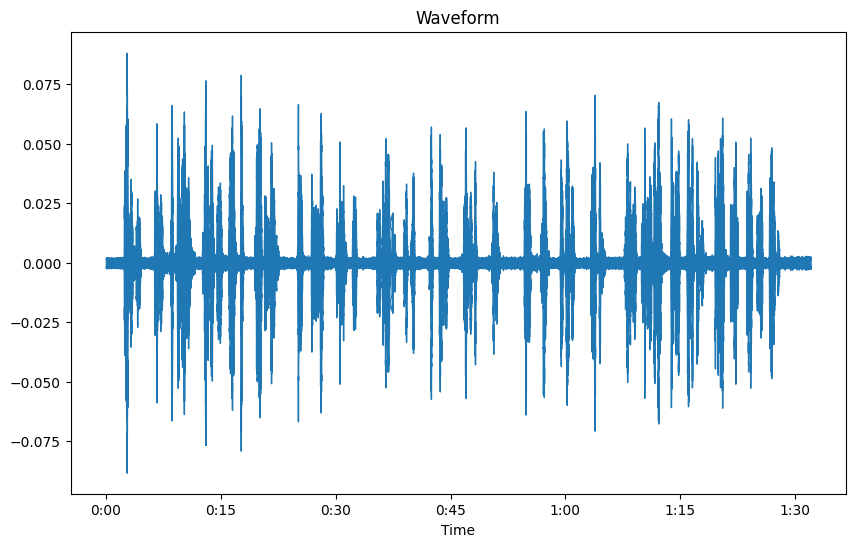

Peak Level (linear scale): 0.088
RMS Level (linear scale): 0.007
RMS Level (dBFS): -43.23 dB

Frequency Band Power (dB):
Super Low (< 50Hz): -42.61 dB
Low (50Hz - 400Hz): -0.14 dB
Mid (400Hz - 4kHz): -17.92 dB
High (> 4kHz): -66.08 dB

Interpretation:
- Your recording is softer than typical levels for spoken content. Consider amplifying.


In [19]:
wav_analyze_gain(file_path) # CHECK AMPLITUDE FOR GAIN PURPOSES - ### low GAIN  ### CLIPPING WARNING

###  <<< 2 >>>  FREQUENCY ANALYSIS:

##### 0 to 50 Hz: Purpose: This very low-end range provides the rumble and sub-bass content. --->  < 5% 
##### 50 to 400 Hz: freq of male voices mostly reside here, giving the voice body/fullness.  --->  ~ 40%
##### 400 to 4000 Hz: freq w harmonic content, presence/clarity. vital for intelligibility.  --->  ~ 55%

In [20]:
# wav_freq_dist_pie_chart(file_path) # CHECK FREQ DISTRIUTION
# wav_freq_dist_plot(file_path) # check freq distributions PLOTS
# wav_plot_spectrogram(file_path)

# # FURTHER ANALYSIS--------- PLOTS

# wav_plot_3(file_path)
# wav_audio_ana_6(file_path)

# # AFTER MODIFyING COMPARE FOLDER ----------- ALL wavs in FOLDER PLOTS
# direc_wav_compare_spct(direc_wav)

# <<< 3 4 5 >>> AUDIO EDITING

In [21]:
# HP functions
from _ms_pod_editing_functions import wav_hp_mod_1
# NR functions
from _ms_pod_editing_functions import wav_nr_mod_1 ,wav_nr_mod_2
# NOISE GATE
from _ms_pod_editing_functions import wav_ng_mod_1, wav_ng_mod_2_pad
# NORMALIZATION 

from _ms_pod_editing_functions import wav_norm_first, wav_comp_norm_lufs

#from _ms_pod_editing_functions import

print(f' EDITING functions working currently in ::: \n*\n*\n*\n*{file_path}\n*\n*\n*\n*')

 EDITING functions working currently in ::: 
*
*
*
*/Users/yerik/Downloads/BF/YERIKO_AUDIO/1_bf25Yeriko_(Vocals).wav
*
*
*
*


# PRE  NOCH + high pass +filter 

In [33]:
# -----######-----###### MULTI-NOTCH VIBRATION CLEANER -----######-----###### #
import os
import numpy as np
import librosa
import soundfile as sf
import scipy.signal as signal
from tqdm import tqdm
import matplotlib.pyplot as plt

def _denoise_2207_multinoise_GET_clean_audio(
    input_audio_path,
    num_peaks=3,
    notch_q=40,
    hp_cutoff=50,
    plot=False
):
    """
    Removes low-end vibration using multiple notch filters + high-pass filtering.
    
    Parameters:
    - input_audio_path: full path to input WAV/AIFF/MP3
    - num_peaks: how many strong frequencies to suppress (vibration noise)
    - notch_q: notch filter Q (sharpness, higher = narrower)
    - hp_cutoff: high-pass filter cutoff (Hz)
    - plot: if True, show frequency spectrum before/after
    
    Returns:
    - output_path: cleaned file path
    """

    y, sr = librosa.load(input_audio_path, sr=None, mono=True)
    duration_sec = round(len(y) / sr, 2)
    print(f"📎 Loaded: {input_audio_path}\n📏 Duration: {duration_sec}s @ {sr} Hz")

    # 1. FFT to find noise peaks
    N = len(y)
    fft_spectrum = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(N, d=1/sr)

    low_band = freqs < 250  # we only care about hum/buzz
    top_freqs = freqs[low_band]
    top_mags = fft_spectrum[low_band]

    # Get top N peaks
    peak_indices = np.argpartition(top_mags, -num_peaks)[-num_peaks:]
    peak_freqs = top_freqs[peak_indices]
    peak_freqs = sorted(peak_freqs)

    print(f"🎯 Detected noise peaks: {['%.1fHz' % f for f in peak_freqs]}")

    # 2. Apply notch filters for each peak
    for f0 in peak_freqs:
        b, a = signal.iirnotch(f0, notch_q, sr)
        y = signal.filtfilt(b, a, y)

    # 3. High-pass filter (to kill rumble)
    sos = signal.butter(4, hp_cutoff, btype='highpass', fs=sr, output='sos')
    y = signal.sosfilt(sos, y)

    # 4. Output
    base, ext = os.path.splitext(input_audio_path)
    output_path = f"{base}_cleaned{ext}"
    sf.write(output_path, y, sr)
    print(f"✅ Saved cleaned audio: {output_path}")

    # 5. Optional plot
    if plot:
        plt.figure(figsize=(10, 4))
        plt.semilogx(freqs, 20 * np.log10(fft_spectrum), label='Before')
        fft_after = np.abs(np.fft.rfft(y))
        plt.semilogx(freqs, 20 * np.log10(fft_after), label='After', alpha=0.7)
        for f0 in peak_freqs:
            plt.axvline(x=f0, color='red', linestyle='--', alpha=0.4)
        plt.title("FFT Spectrum Before/After Filtering")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude (dB)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return output_path


📎 Loaded: /Users/yerik/Downloads/BF/YERIKO_AUDIO/1_bf25Yeriko_(Vocals).wav
📏 Duration: 92.02s @ 44100 Hz
🎯 Detected noise peaks: ['89.2Hz', '89.7Hz', '90.6Hz']
✅ Saved cleaned audio: /Users/yerik/Downloads/BF/YERIKO_AUDIO/1_bf25Yeriko_(Vocals)_cleaned.wav


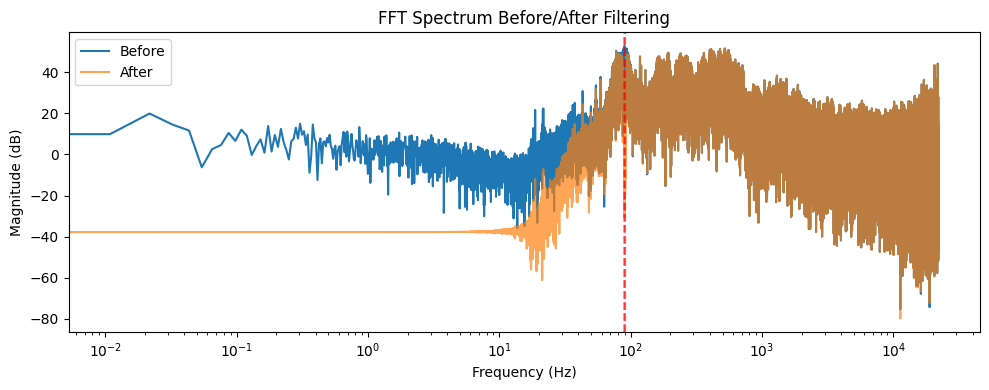

In [34]:
# ✅ Set your input path
input_path = "/Users/yerik/Downloads/BF/YERIKO_AUDIO/1_bf25Yeriko_(Vocals).wav"

# ✅ Path to your buzzing audio

# ✅ Run the multi-notch fixer
cleaned_path = _denoise_2207_multinoise_GET_clean_audio(
    input_path,
    num_peaks=3,     # Try 3-5 if really buzzy
    notch_q=40,      # Keep sharp
    hp_cutoff=50,    # Retains warmth, removes low rumble
    plot=True        # Shows you what's being filtered
)



### ::: 3a ::: High Pass

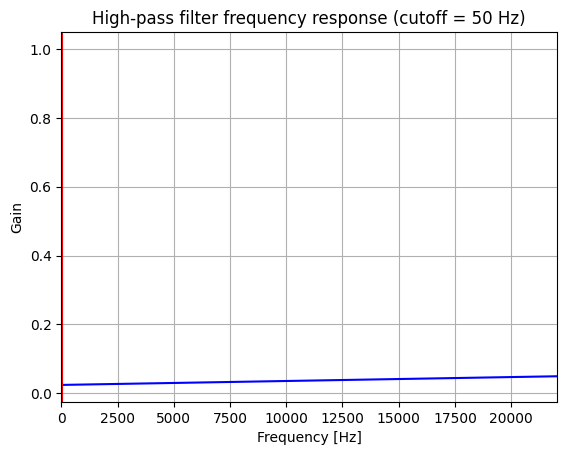

In [22]:
# Usage example
y_hpf, sr = wav_hp_mod_1(file_path, cutoff_frequency=50, order=6)

# Save the high-pass filtered audio
out_file_path_hp_m1 = f"{direc_wav}/_1_vr_raw_iii_HP50"
# Write
sf.write(f'{out_file_path_hp_m1}.wav', y_hpf, sr)

### ::: 3b ::: Noise Reduction (NR) mod_1

In [23]:
# Usage
# Adjust 'audio_path', 'noise_reduction_level', and 'sensitivity' as needed
noise_reduced_output_1 = wav_nr_mod_1(f'{out_file_path_hp_m1}.wav', 0.9, 0.9)

# Save the high-pass filtered audio
out_file_path_nr_m1 = f"{direc_wav}/_2_vr_HP50_iii_NR"
# Write
sf.write(f'{out_file_path_nr_m1}.wav', noise_reduced_output_1, sr)
# Write to a file


##### Noise Reduction (NR) mod_2

In [24]:
# Adjust 'audio_file_path', 'noise_reduction_factor', 'frame_length', and hop_length' as needed
noise_reduced_output_2, sample_rate = wav_nr_mod_2(f'{out_file_path_nr_m1}.wav', 0.8)


# Save the high-pass filtered audio
out_file_path_nr_m2 = f"{direc_wav}/_2b_vr_NR_iii_NR_mod_2"
# Write
sf.write(f'{out_file_path_nr_m2}.wav', noise_reduced_output_2, sample_rate)
# Write to a file


### ::: 3c ::: NOISE GATE - NOT PADDiNG - for low volumes (-80,-60) -- mod_1

In [25]:
#So, 0.01 seconds is equivalent to 10 milliseconds. , attack ~ .01 , release~ .3 (300)

input_file = f'{out_file_path_nr_m2}.wav'
#input_file = f'{out_file_path_nr_m1}.wav' # SKIP NR_2


out_file_path_ng_m1 = f"{direc_wav}/_3_vr_NR_mod_2_iii_NG-70_ARdot0105"

# SAVE and EXPORT inside the fn 
wav_ng_mod_1(input_file, f'{out_file_path_ng_m1}.wav', gate_threshold=-46.0, attack=0.39, release=.05)

# <<< 4 >>>   NORMALIZATION and Second NOiSE GATE

#### ::: 4a ::: first Normalization - PEAK NORMALIZATION

In [26]:


# Assume the normalize_audio function is already defined as provided earlier
norm_type = 'peak'  # or 'rms'
# Using the function
input_file_path = f'{out_file_path_ng_m1}.wav' # Replace with your input file path
out_file_path_norm_1 = f"{direc_wav}/_4_vr_NORM_{norm_type}"#{my_level}"

norm_1_audio,sample_rate = wav_norm_first(input_file_path, normalization_type=norm_type, target_level=-0.9)

# Export the normalized audio to a file
sf.write(f"{out_file_path_norm_1}.wav",norm_1_audio, sample_rate)


#### ::: 4b ::: second NG

In [27]:


input_file_path = f'{out_file_path_norm_1}.wav' # Replace with your input file path

out_file_path_norm_ng = f"{direc_wav}/_4b_vr_NORM_{norm_type}_to_NG"#{my_level}"


wav_ng_mod_2_pad(input_file_path, f"{out_file_path_norm_ng}.wav", gate_threshold=-63.0, attack=0.19, release=0.02)


# <<< 5 >>> COMPRESSION and LAST NORMALIZATIONzz

In [28]:
# Usage
input_file = f"{out_file_path_norm_ng}.wav"#{my_level}"

out_comp_norm_lufs = f"{direc_wav}/_5_vr_LUFS_comp_and_norm"

wav_comp_norm_lufs(input_file, f"{out_comp_norm_lufs}.wav", threshold=-0.95, ratio=2.0, attack=0.29, release=0.02, target_lufs=-26.0)


# END

In [ ]:
# further research - DE- ESSER and MULTI BADN COMOPRESSOR 

# NOTES

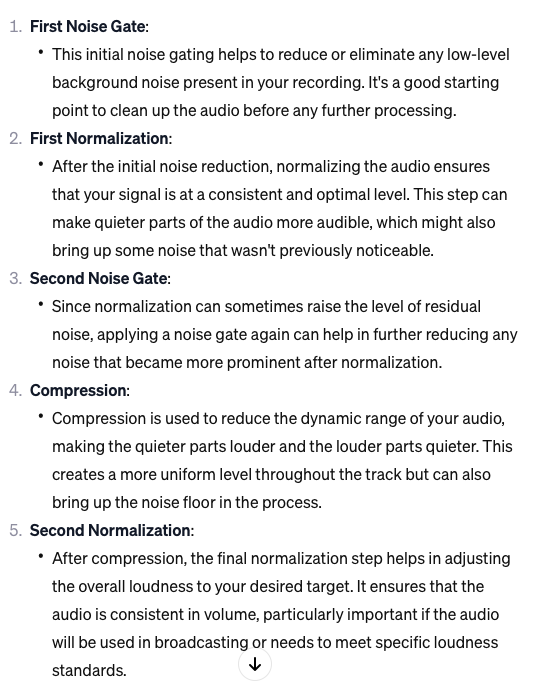

Both steps are crucial for professional audio processing, especially for podcasts and broadcast content. Compression ensures consistent audibility within the track, and LUFS normalization ensures that the overall loudness meets the standards of the intended platform, providing a uniform listening experience. This combination is key to achieving high-quality, platform-compliant audio content.

Adjust the Compression Threshold: Lowering the compression threshold means that more parts of the audio will be subjected to compression

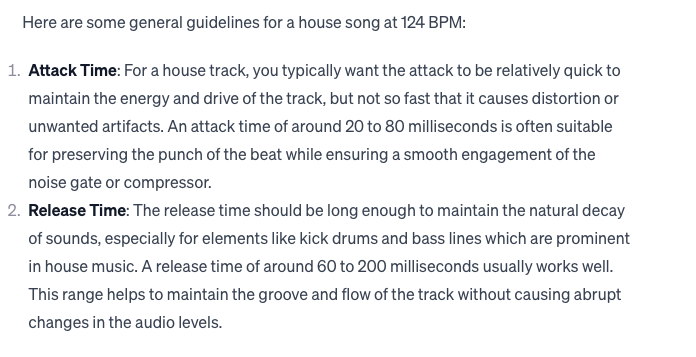